# 课程设计：基于作业一至三的人工智能文本挖掘综合实践

**学生**：陈喜盈 (3223004641)  
**课程**：文本信息挖掘概论

本 Notebook 整合作业一（语料采集）、作业二（定制词典与新词挖掘）、作业三（主题降维与推荐）的实验成果。

## 1. 环境准备与数据加载

In [1]:
import json
import os
from data_integration import load_integrated_corpus

integrated = load_integrated_corpus()
print(f"中文文档: {len(integrated['chinese_ai']['docs'])}")
print(f"英文文档: {len(integrated['newsgroups']['docs'])}")
print(f"作业二词典统计: {integrated['hw2_dict_stats']}")

中文文档: 75
英文文档: 120
作业二词典统计: {'AI 种子词数': '31', '财经 种子词数': '34', 'AI 最终词典词数': '223', '财经 最终词典词数': '226'}


## 2. 作业一语料统计展示

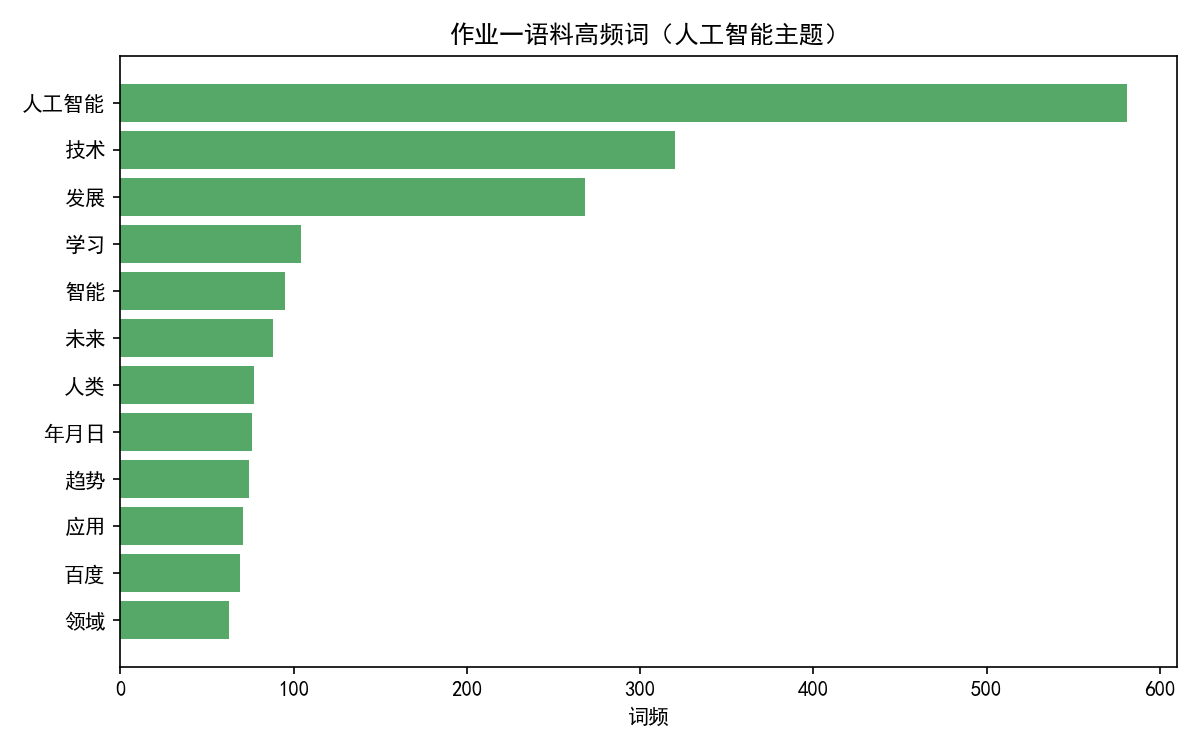

In [2]:
from IPython.display import Image, display

out = os.path.join('output', 'hw1_word_freq.png')
if os.path.isfile(out):
    display(Image(filename=out))
else:
    print('请先运行 python main.py')

## 3. 新词爆发力指数（设计亮点）

In [6]:
from newword_evaluator import evaluate_new_words

scores = evaluate_new_words(
    integrated['chinese_ai']['docs'],
    integrated['seed_words'],
    integrated['user_dict_words'],
)
for s in scores[:10]:
    print(f"{s['word']:12s} 爆发力={s['burst_index']:.4f}  TF={s['tf']}  DF={s['df']}")

技术           爆发力=1.0000  TF=660  DF=25
智能           爆发力=0.8898  TF=597  DF=19
发展           爆发力=0.8705  TF=486  DF=23
研究           爆发力=0.8166  TF=496  DF=18
应用           爆发力=0.7599  TF=343  DF=21
人类           爆发力=0.7398  TF=389  DF=17
领域           爆发力=0.7105  TF=321  DF=18
模型           爆发力=0.7097  TF=379  DF=15
生成           爆发力=0.6552  TF=388  DF=10
计算机          爆发力=0.6539  TF=287  DF=15


## 4. 运行完整流水线

In [7]:
from pipeline import run_full_pipeline

report = run_full_pipeline()
print('新词 Top5:', [w['word'] for w in report['newword_scores'][:5]])

D:\vscode\dataCollection\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
D:\vscode\dataCollection\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


课程设计流水线完成，输出目录: D:\vscode\dataCollection\curriculum_design\output
新词 Top5: ['技术', '智能', '发展', '研究', '应用']


## 5. 主题嵌入可视化

chinese_ai_embed_pca.png


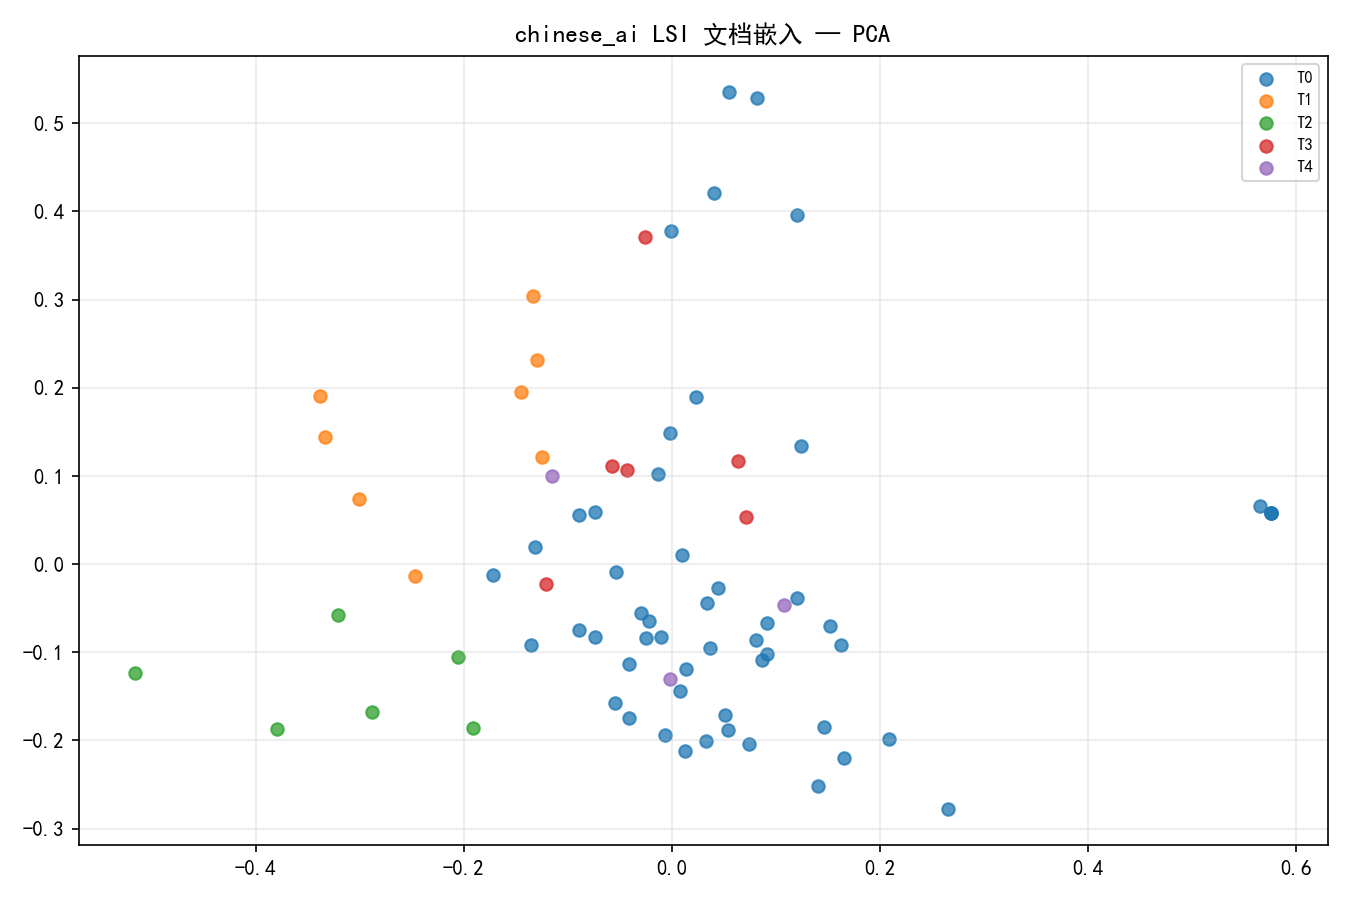

chinese_ai_embed_umap.png


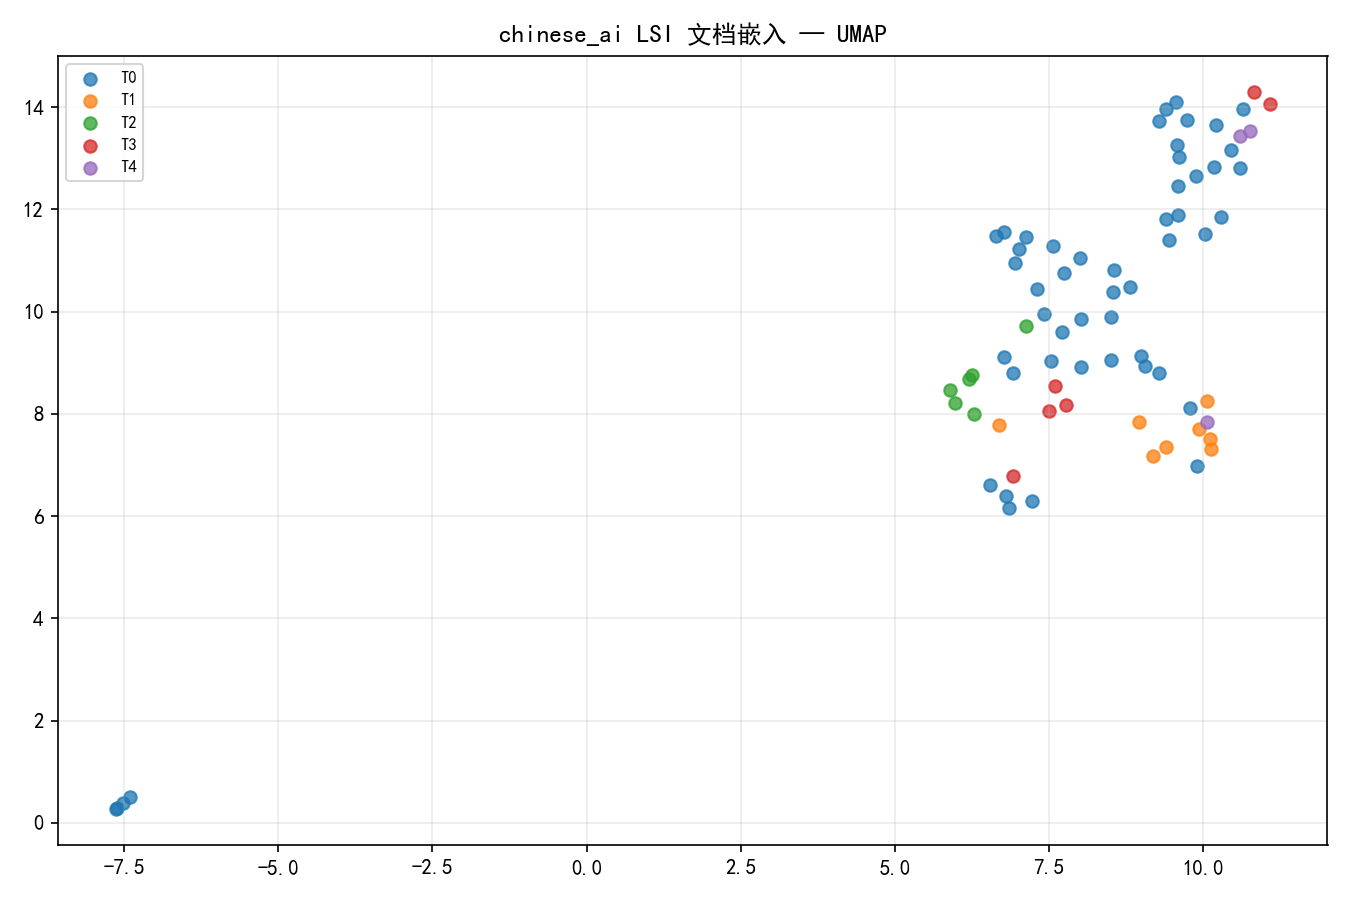

newword_burst_index.png


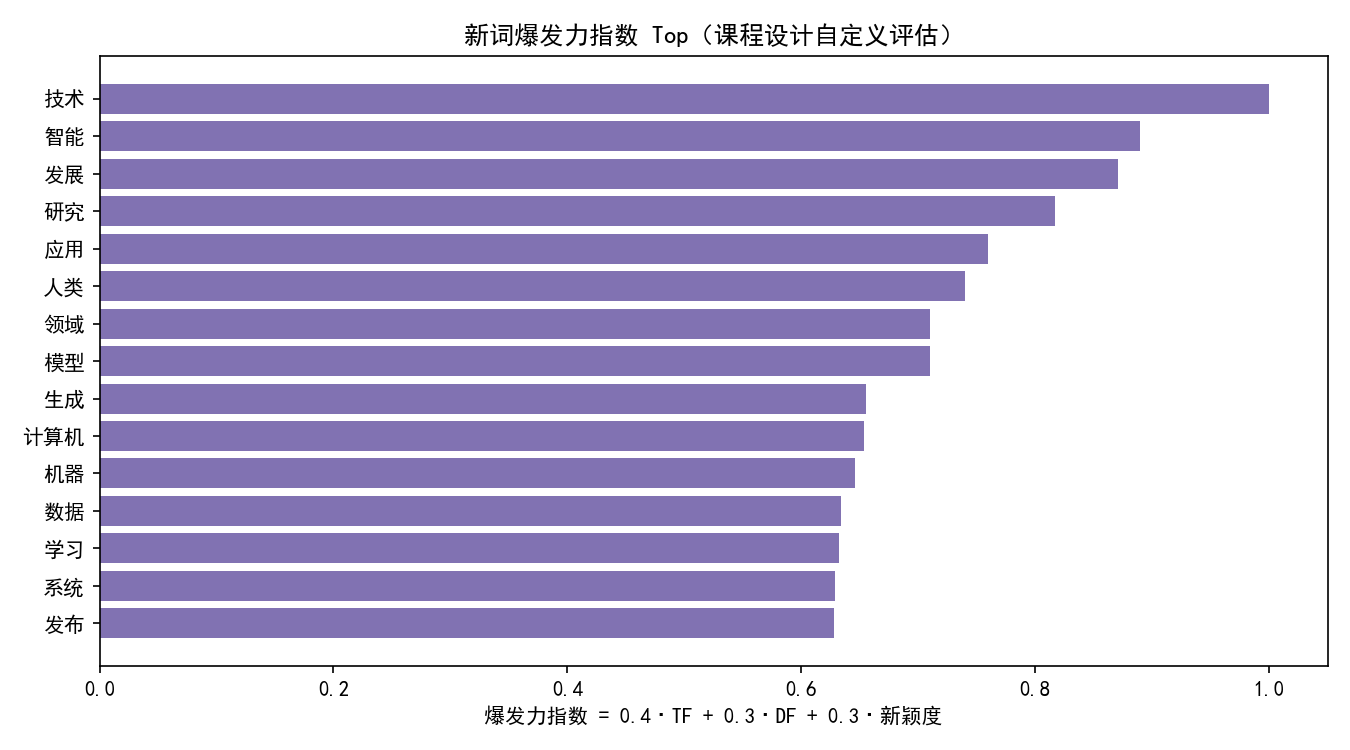

In [5]:
for fname in ['chinese_ai_embed_pca.png', 'chinese_ai_embed_umap.png', 'newword_burst_index.png']:
    path = os.path.join('output', fname)
    if os.path.isfile(path):
        print(fname)
        display(Image(filename=path))

## 6. 生成 Word 报告

In [ ]:
from gen_docx import main as gen_docx
gen_docx()